# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

In [ ]:
!pip install pandas

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [141]:
df = pd.read_csv("../data/checker_submits.csv")

In [142]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek

df

,uid,labname,numTrials,timestamp,hour,dayofweek
0,user_4,project1,1,2020-04-17 05:19:02.744528,5,4
1,user_4,project1,2,2020-04-17 05:22:45.549397,5,4
2,user_4,project1,3,2020-04-17 05:34:24.422370,5,4
3,user_4,project1,4,2020-04-17 05:43:27.773992,5,4
4,user_4,project1,5,2020-04-17 05:46:32.275104,5,4
...,...,...,...,...,...,...
1681,user_19,laba06s,9,2020-05-21 20:01:48.959966,20,3
1682,user_1,laba06s,6,2020-05-21 20:18:54.487900,20,3
1683,user_1,laba06s,7,2020-05-21 20:19:06.872761,20,3
1684,user_1,laba06s,8,2020-05-21 20:22:41.877806,20,3


In [143]:
encoder = OneHotEncoder(sparse_output=False)
encoded_features = encoder.fit_transform(df[["uid", "labname"]])
feature_names = encoder.get_feature_names_out(["uid", "labname"])
encoded_df = pd.DataFrame(encoded_features, columns=feature_names)
df = pd.concat([encoded_df, df[["numTrials", "hour", "dayofweek"]]], axis=1)


df


,uid_user_0,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,...,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,numTrials,hour,dayofweek
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,5,4
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2,5,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3,5,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4,5,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9,20,3
1682,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,6,20,3
1683,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7,20,3
1684,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,8,20,3


In [144]:
Scaler = StandardScaler()
df[["numTrials", "hour"]] = Scaler.fit_transform(df[["numTrials", "hour"]])

In [145]:
df.to_csv("dayofweek.csv", index=False)

In [ ]:
naive = df["dayofweek"].mode()[0]
df_copy = df.copy()
df_copy["naive_predict"] = naive                 
accuracy = accuracy_score(df["dayofweek"], df_copy["naive_predict"])

accuracy

0.23487544483985764

## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [77]:
X_train = df.iloc[:, 0:43]
X_train["hour"] = df["hour"]
Y_train = df["dayofweek"]

In [78]:
model = LogisticRegression(random_state=21, fit_intercept=False, multi_class='ovr', solver='liblinear')
model.fit(X_train, Y_train)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1288: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'liblinear'
,max_iter,100
,multi_class,'ovr'


In [68]:
y_pred = model.predict(X_train)
df["predict"] = y_pred
accuracy = accuracy_score(Y_train, y_pred)

accuracy

0.6269276393831554

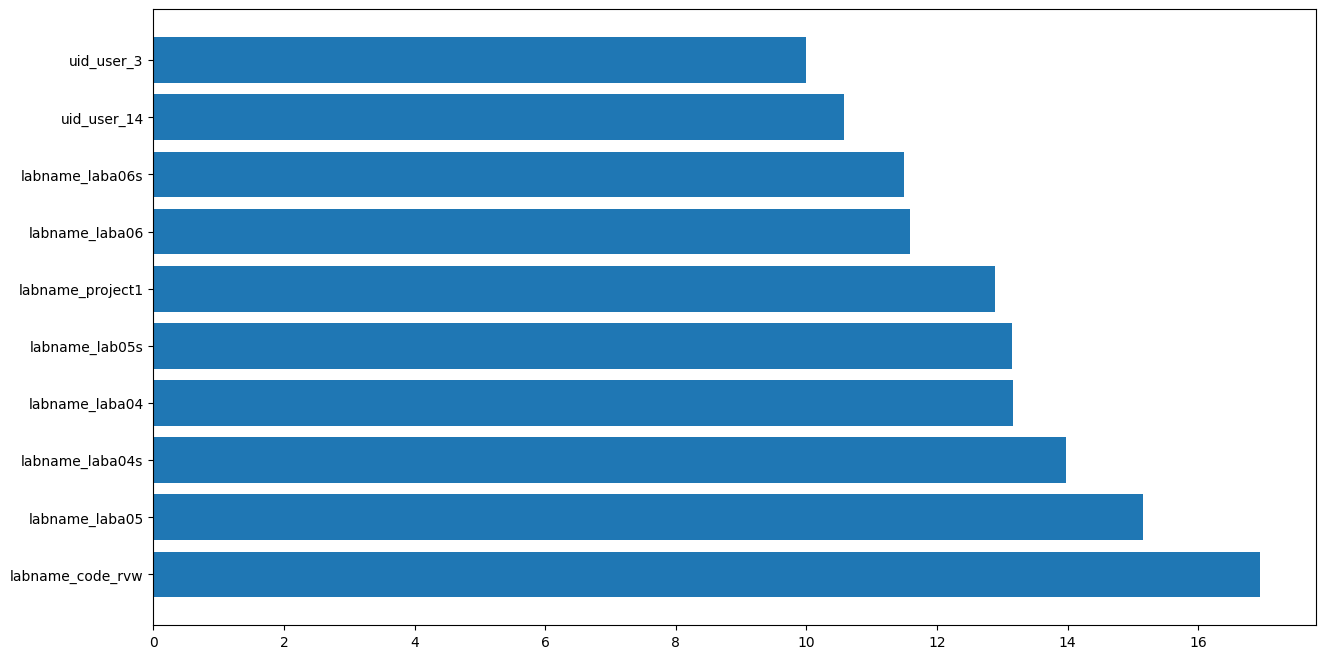

In [79]:
def top_n_features(n):
    coef = model.coef_
    sum_coef = np.abs(np.sum(np.abs(coef), axis=0))
    sum_coef = pd.Series(sum_coef)
    features = (np.array(X_train.columns))

    data = pd.DataFrame()
    data["coef"] = sum_coef
    data["features"] = features
    data = data.sort_values(by=["coef"], ascending=False)
    data = data.iloc[:n, :]

    plt.figure(figsize=(15,8))
    plt.barh(y=data["features"], width=data["coef"])
    plt.show()



top_n_features(10)
    

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [60]:
model = OneVsRestClassifier(SVC(probability=True, random_state=21, kernel='linear'))
model.fit(X_train, Y_train)
y_pred_svc = model.predict(X_train)
accuracy_svc = accuracy_score(Y_train, y_pred_svc)

accuracy_svc

0.6126927639383155

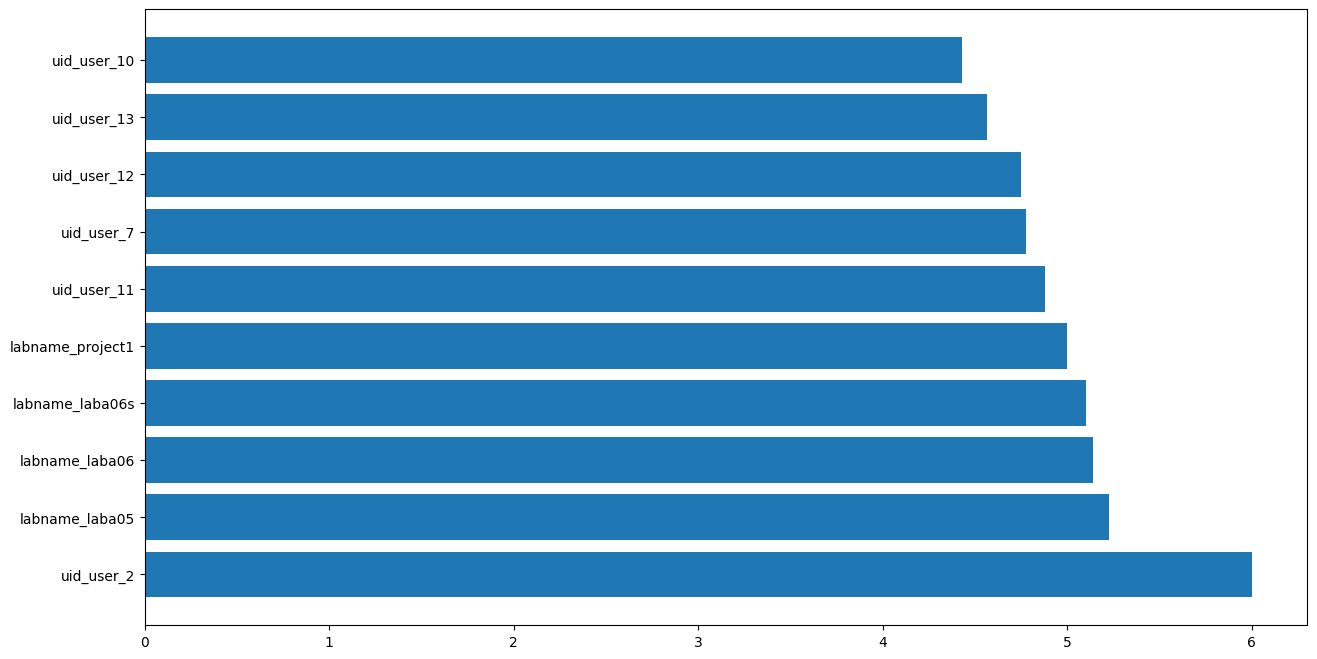

In [61]:
def top_n_features(n):
    coef = [clf.coef_[0] for clf in model.estimators_]
    sum_coef = np.abs(np.sum(np.abs(coef), axis=0))
    sum_coef = pd.Series(sum_coef)

    features = X_train.columns
    features = pd.Series(features)

    data = pd.DataFrame()
    data["coef"] = sum_coef
    data["features"] = features
    data = data.sort_values(by=["coef"], ascending=False)
    data = data.iloc[:n, :]

    plt.figure(figsize=(15,8))
    plt.barh(y=data["features"], width=data["coef"])
    plt.show()

top_n_features(10)


In [47]:
model = OneVsRestClassifier(SVC(probability=True, random_state=21, kernel='poly'))
model.fit(X_train, Y_train)
y_pred_svc = model.predict(X_train)
accuracy_svc = accuracy_score(Y_train, y_pred_svc)

accuracy_svc

0.8653618030842231

In [46]:
model = OneVsRestClassifier(SVC(probability=True, random_state=21, kernel='rbf'))
model.fit(X_train, Y_train)
y_pred_svc = model.predict(X_train)
accuracy_svc = accuracy_score(Y_train, y_pred_svc)

accuracy_svc

0.8641755634638197

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [82]:
clf = tree.DecisionTreeClassifier(max_depth=4, random_state=21)
clf.fit(X_train, Y_train)

y_pred_tree = clf.predict(X_train)
accuracy = accuracy_score(Y_train, y_pred_tree)

accuracy

0.5516014234875445

[Text(0.5416666666666666, 0.9, 'x[40] <= 0.5\ngini = 0.83\nsamples = 1686\nvalue = [136, 274, 149, 396, 104, 271, 356]'),
 Text(0.3125, 0.7, 'x[37] <= 0.5\ngini = 0.74\nsamples = 735\nvalue = [28.0, 49.0, 41.0, 71.0, 41.0, 227.0, 278.0]'),
 Text(0.4270833333333333, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'x[39] <= 0.5\ngini = 0.72\nsamples = 513\nvalue = [28, 47, 36, 53, 8, 106, 235]'),
 Text(0.08333333333333333, 0.3, 'x[35] <= 0.5\ngini = 0.672\nsamples = 452\nvalue = [27.0, 32.0, 19.0, 31.0, 8.0, 105.0, 230.0]'),
 Text(0.041666666666666664, 0.1, 'gini = 0.564\nsamples = 274\nvalue = [16.0, 19.0, 9.0, 19.0, 4.0, 32.0, 175.0]'),
 Text(0.125, 0.1, 'gini = 0.719\nsamples = 178\nvalue = [11.0, 13.0, 10.0, 12.0, 4.0, 73.0, 55.0]'),
 Text(0.25, 0.3, 'x[17] <= 0.5\ngini = 0.725\nsamples = 61\nvalue = [1, 15, 17, 22, 0, 1, 5]'),
 Text(0.20833333333333334, 0.1, 'gini = 0.704\nsamples = 54\nvalue = [1, 8, 17, 22, 0, 1, 5]'),
 Text(0.2916666666666667, 0.1, 'gini = 0.0\nsamples = 7\nvalue

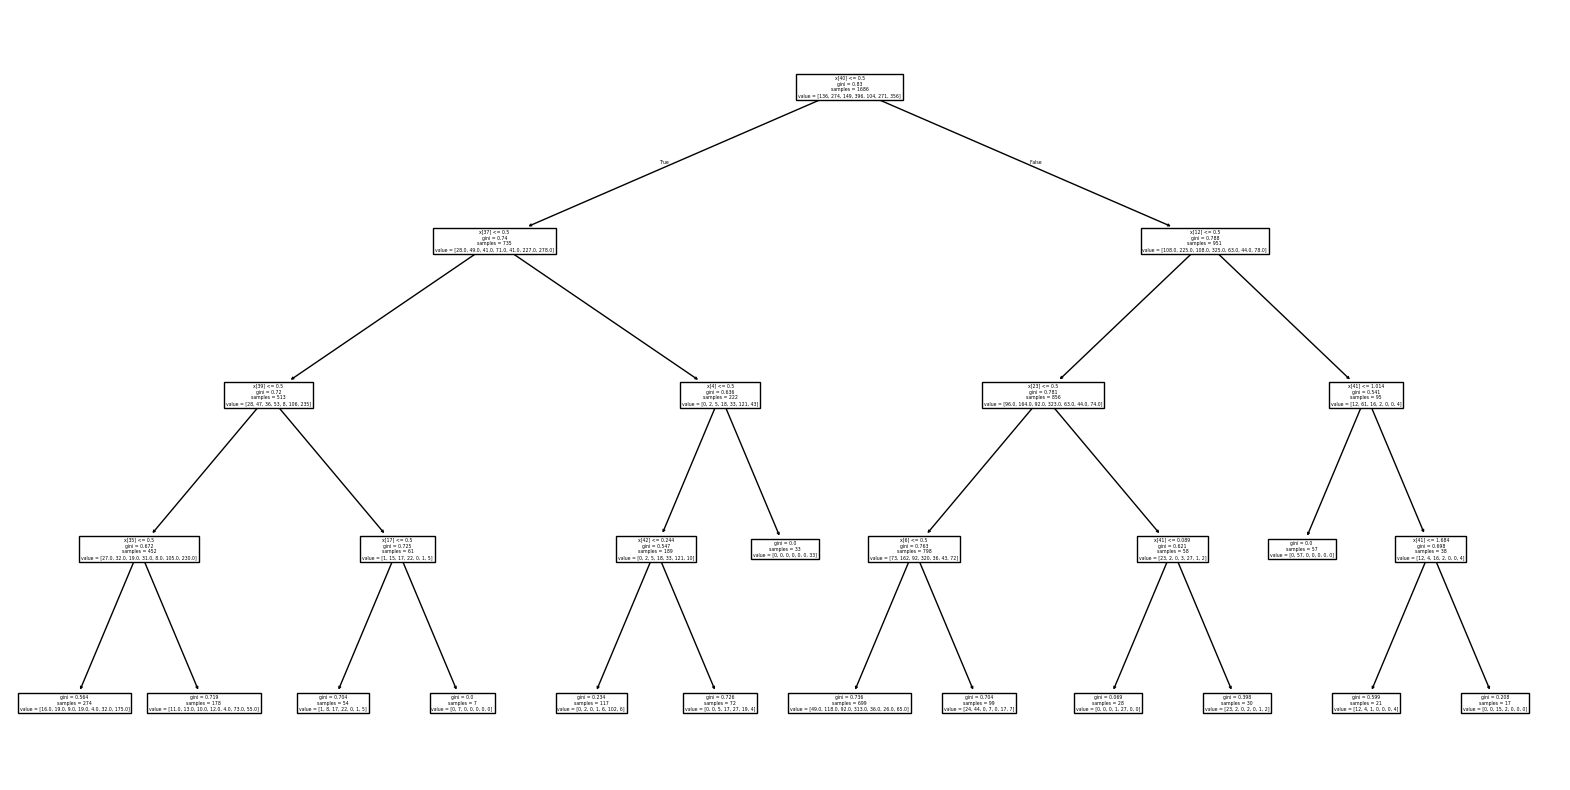

In [63]:
plt.figure(figsize=(20,10))
tree.plot_tree(clf)

In [49]:
clf = tree.DecisionTreeClassifier(max_depth=12, random_state=21)
clf.fit(X_train, Y_train)

y_pred_tree = clf.predict(X_train)
accuracy = accuracy_score(Y_train, y_pred_tree)

accuracy

0.8831553973902728

In [81]:
clf = tree.DecisionTreeClassifier(max_depth=27, random_state=21)
clf.fit(X_train, Y_train)

y_pred_tree = clf.predict(X_train)
accuracy = accuracy_score(Y_train, y_pred_tree)

accuracy

0.9988137603795967

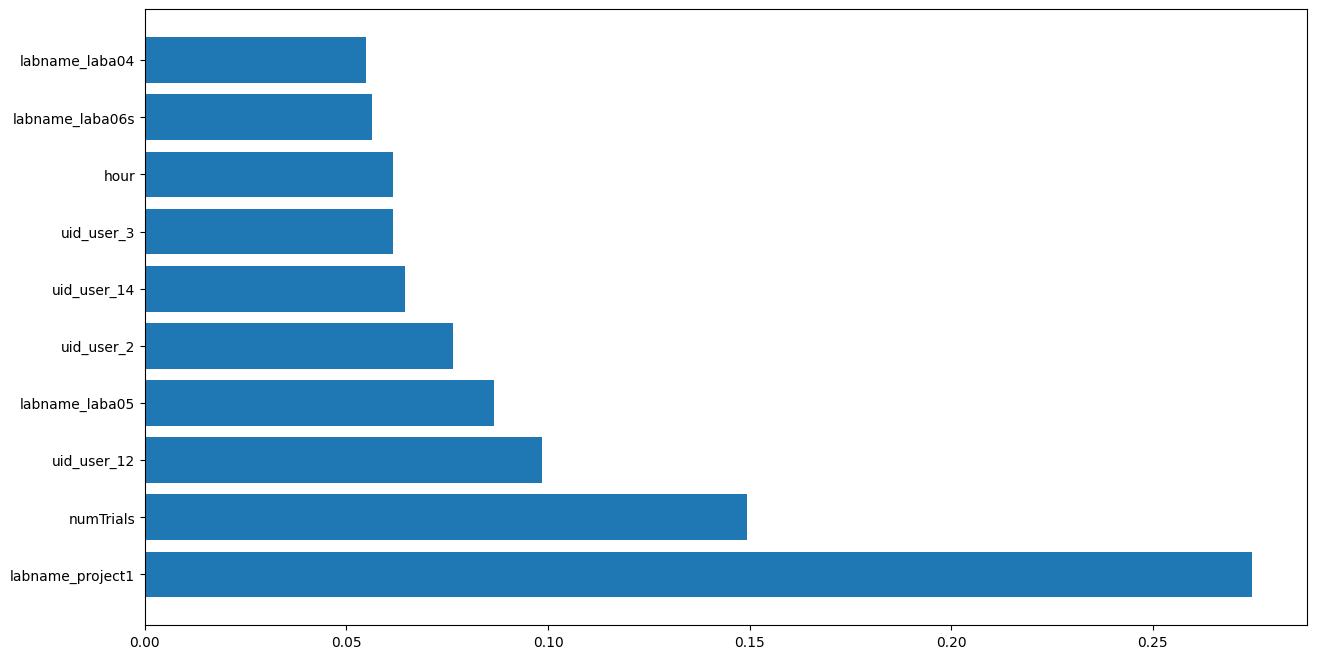

In [83]:
importances = clf.feature_importances_
features = X_train.columns

data = pd.DataFrame()
data["coef"] = importances
data["features"] = features
data = data.sort_values(by=["coef"], ascending=False)
data = data.iloc[:10, :]

plt.figure(figsize=(15,8))
plt.barh(width=data["coef"], y=data["features"])
plt.show()


### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [100]:
clf = RandomForestClassifier(n_estimators=100, max_depth=24, random_state=21)
clf.fit(X_train, Y_train)

y_pred_forest = clf.predict(X_train)
accuracy = accuracy_score(Y_train, y_pred_forest)

accuracy


0.9994068801897983

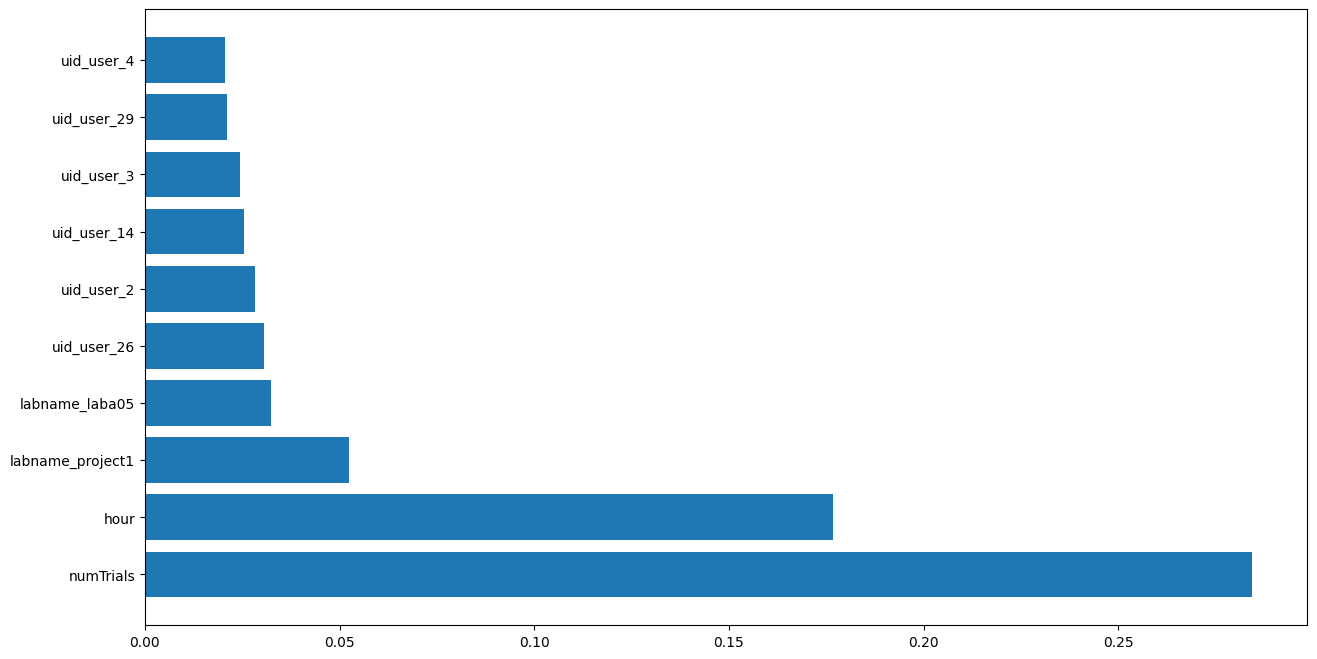

In [85]:
def top_10_features():
    features_imp = pd.DataFrame()
    features_imp["imp"] = clf.feature_importances_
    features_imp["features"] = X_train.columns
    features_imp = features_imp.sort_values(by=["imp"], ascending=False)
    features_imp = features_imp.iloc[:10, :]

    plt.figure(figsize=(15,8))
    plt.barh(width=features_imp["imp"], y=features_imp["features"])
    plt.show()

top_10_features()